In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm

import imageio
import os
import shutil

# Functions

In [7]:
class Chromosomes():
    def __init__(self, chromosomes_gene_type, chromosomes_gene_mut, gene_map):
        self.chromosomes_gene_type = [list(chrom) for chrom in chromosomes_gene_type]
        self.chromosomes_gene_mut = [list(chrom) for chrom in chromosomes_gene_mut]
        self.gene_map = gene_map

    def get_Nchrs(self):
        if len(self.chromosomes_gene_type)==len(self.chromosomes_gene_mut):
            return len(self.chromosomes_gene_type)
        else:
            return "Error"
    
    def mutate(self, mu):
        # Random gene mutation with rate mu
        n_mut = 0
        for i in range(self.get_Nchrs()):
            for j in range(len(self.chromosomes_gene_mut[i])):
                if np.random.rand() < mu:
                    self.chromosomes_gene_mut[i][j] = 1
                    #print("mut")
                    n_mut += 1
        return n_mut
        
    def crossover(self, ext_chr_gt, ext_chr_gm):
        idx_chr = np.random.randint(0, self.get_Nchrs()) # Random pick the index of the chromosome to crossover
        # Add new genes to the chosen chromosome
        self.chromosomes_gene_type[idx_chr].extend(ext_chr_gt)
        self.chromosomes_gene_mut[idx_chr].extend(ext_chr_gm)

    def get_genes_by_type(self, gene_type):
        """
        gene_type: str
            Gene type to search for, can be one between "I", "O", "S", "HK"
        """
        #apply the gene map tp chrom_gene_type
        mapped_chromosomes = [[self.gene_map[x] for x in chr] for chr in self.chromosomes_gene_type]
        restr_gene_mut_gt = []
        restr_gene_mut_gm = []
        for i in range(len(mapped_chromosomes)):
            mc = np.array(mapped_chromosomes[i])
            restr_gene_mut_gt.append(np.array(self.chromosomes_gene_type[i])[mc==gene_type])
            restr_gene_mut_gm.append(np.array(self.chromosomes_gene_mut[i])[mc==gene_type])
        return restr_gene_mut_gt, restr_gene_mut_gm

In [8]:
class Cell():
    def __init__(self, x, y, mu0, r0, chromosomes):
        self.x = x
        self.y = y
        self.mu0 = mu0
        self.mu = mu0
        self.r0 = r0
        self.r = r0
        self.chromosomes = chromosomes

    def get_Nchrs(self):
        return self.chromosomes.get_Nchrs()
    
    def update_mu(self, dmu):
        i_genes = self.chromosomes.get_genes_by_type("I")
        unique_genes = np.unique(np.concatenate(i_genes[0]))
        act_per_chr = []
        for nc in range(len(i_genes[0])):
            act_per_chr.append(np.zeros(len(unique_genes)))
            for i in range(len(unique_genes)):
                act_per_chr[nc][i] = int(np.any(i_genes[1][nc][i_genes[0][nc]==unique_genes[i]])) 
        act_per_chr = np.array(act_per_chr)
        act_per_gene = np.any(act_per_chr, axis=0) # ANY to have an increase in the rate of mutation, the gene has to be mutated in at least one chromosomes
        self.mu = self.mu0 + np.sum(act_per_gene)*dmu

    def update_r(self, dr):
        # Contribution of Oncogenic genes
        o_genes = self.chromosomes.get_genes_by_type("O")
        unique_genes = np.unique(np.concatenate(o_genes[0]))
        act_per_chr = []
        for nc in range(len(o_genes[0])):
            act_per_chr.append(np.zeros(len(unique_genes)))
            for i in range(len(unique_genes)):
                act_per_chr[nc][i] = int(np.any(o_genes[1][nc][o_genes[0][nc]==unique_genes[i]])) 
        act_per_chr = np.array(act_per_chr)
        act_per_gene_o = np.any(act_per_chr, axis=0) # ANY to have an increase in the rate of mutation, the gene has to be mutated in at least one chromosome

        #Contribution of tumor Suppressor Genes
        s_genes = self.chromosomes.get_genes_by_type("S")
        unique_genes = np.unique(np.concatenate(s_genes[0]))
        act_per_chr = []
        for nc in range(len(s_genes[0])):
            act_per_chr.append(np.zeros(len(unique_genes)))
            for i in range(len(unique_genes)):
                act_per_chr[nc][i] = int(np.any(s_genes[1][nc][s_genes[0][nc]==unique_genes[i]])) 
        act_per_chr = np.array(act_per_chr)
        act_per_gene_i = np.all(act_per_chr, axis=0) # ALL the difference for the tumor suppressor is that they have to be mutated in all the chromosomes
        
        self.r = self.r0 + np.sum(act_per_gene_o)*dr+ np.sum(act_per_gene_i)*dr

    def reproduce(self):
        if np.random.rand() < self.r:
            return True
        else:
            return False

    def check_cell_death(self):
        # If the cell doesn't have any chromosomes, DIES
        if self.get_Nchrs()==0:
            return True
        hk_genes = self.chromosomes.get_genes_by_type("HK")
        unique_genes = np.unique(np.concatenate(hk_genes[0]))
        act_per_chr = []
        for nc in range(len(hk_genes[0])):
            act_per_chr.append(np.zeros(len(unique_genes)))
            for i in range(len(unique_genes)):
                act_per_chr[nc][i] = int(np.all(hk_genes[1][nc][hk_genes[0][nc]==unique_genes[i]])) # if one chromosome has more than one copy of a HK gene, it suffices that at least one is not mutated
        act_per_chr = np.array(act_per_chr)
        act_per_gene_hk = np.all(act_per_chr, axis=0) # ANY if at least one of the genes in the different chromosome works, we are ok
        if np.any(act_per_gene_hk)==True:
            return True
        else:
            return False

    def update(self, dr=0.01, dmu=0.005):
        #First of all check if the cell don't mean the confditions to be alive
        if self.check_cell_death():
            return 0 #Death
        
        # If it's ok update the internal parameters
        # MODIFICATION OF DNA
        # mutation
        self.chromosomes.mutate(self.mu)
        # update mutation rate
        self.update_mu(dmu) 

        # REPRODUCTION
        # update reproduction rate
        self.update_r(dr)
        
        # Check for randominc reproduciton
        if self.reproduce():
            return 1 #Reproduce
        else:
            return 2 #Nothing

    def copy(self):
        # Create a deep copy of the chromosomes
        new_chromosomes = Chromosomes([list(chrom) for chrom in self.chromosomes.chromosomes_gene_type],
                                      [list(chrom) for chrom in self.chromosomes.chromosomes_gene_mut],
                                      self.chromosomes.gene_map)
        # Return a new instance of Cell with the same attributes
        return Cell(self.x, self.y, self.mu, self.r, new_chromosomes)

    def replicate_split_chromosomes(self):
        """
        Replicating but splitting not equally the chromosomes
        here we suppose that we can have at max 1 chromosome change
        and that the mother cell has 1 less while the dauther 1 more
        """
        idx_chr = np.random.choice(np.arange(self.get_Nchrs()))
        
        mother = self.copy()
        mother.chromosomes.chromosomes_gene_type.remove(mother.chromosomes.chromosomes_gene_type[idx_chr])
        mother.chromosomes.chromosomes_gene_mut.remove(mother.chromosomes.chromosomes_gene_mut[idx_chr])
        
        daughter = self.copy()
        daughter.chromosomes.chromosomes_gene_type.insert(-1,daughter.chromosomes.chromosomes_gene_type[idx_chr])
        daughter.chromosomes.chromosomes_gene_mut.insert(-1,daughter.chromosomes.chromosomes_gene_mut[idx_chr])

        return mother, daughter

In [52]:
class Tissue():
    def __init__(self, L, init_cell_state, dr=1e-2, dmu=5e-3, p_poly=1e-3):
        self.L = L
        self.cells = init_cell_state
        self.dr = dr
        self.dmu = dmu
        self.p_poly = p_poly
        self.gene_map = init_cell_state[0][0].chromosomes.gene_map #not elegent but works for now

    def get_neighbors(self, row, col, L):
        """
        Returns a list of (row, col) tuples for neighbors of the cell at (row, col)
        in an L x L grid, including diagonals.
        """
        neighbors = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                # Skip the cell itself
                if dr == 0 and dc == 0:
                    continue
                new_row, new_col = row + dr, col + dc
                # Check that the neighbor is within the grid bounds
                if 0 <= new_row < L and 0 <= new_col < L:
                    neighbors.append([new_row, new_col])
        return neighbors
    
    def get_actions(self):
        """
        Make an update of the state of all the cell and returns the action each one is taking
        """
        actions = np.zeros([self.L, self.L])
        for i in range(self.L):
            for j in range(self.L):
                actions[i,j] = self.cells[i][j].update(dr=self.dr, dmu=self.dmu)
        return actions
    
    def sobstitute(self, action):
        """
        Sobstitutes:
            - Death cells with one of the neighbors with prob proportional to their growth rate
            - One of the neighbors of the replicating cell (with prob inversely proportional to g.r.) with the cell replica
        """
        death_cells = np.array(np.where(action==0)).T
        #sobstitute death cells
        for d in death_cells:
            neighs = self.get_neighbors(d[0],d[1],self.L)
            probs = []
            for n in neighs:
                probs.append(self.cells[n[0]][n[1]].r)
            p = 1/np.array(probs)
            p = p/sum(p)
            selected_neigh = neighs[np.random.choice(np.arange(len(neighs)), p=p)] #select the cells to sobstitute with probability inverse wrt to the reproduction rate

            new_cell = self.cells[selected_neigh[0]][selected_neigh[1]].copy() #I reproduce one of the neigbors proportionaly to the fitness
            self.cells[d[0]][d[1]] = new_cell # and sobstitute with it the death  cell
            
        # multiply reproducing cells
        reproducing_cells = np.array(np.where(action==1)).T
        for r in reproducing_cells:
            neighs = self.get_neighbors(r[0],r[1],self.L)
            probs = []
            for n in neighs:
                probs.append(self.cells[n[0]][n[1]].r)
            selected_neigh = neighs[np.random.choice(np.arange(len(neighs)), p=np.array(probs)/sum(probs))]

            # plyploidity
            if np.random.rand()<self.p_poly:
                old_cell, new_cell = self.cells[r[0]][r[1]].replicate_split_chromosomes()
                #print("ply")
            else:
                old_cell, new_cell = self.cells[r[0]][r[1]], self.cells[r[0]][r[1]].copy()
                
            self.cells[r[0]][r[1]] = old_cell
            self.cells[selected_neigh[0]][selected_neigh[1]] = new_cell  #and sobstitute it with the selected one (least fit)

    def update(self):
        """
        Update the state of the tissue
        """
        action = self.get_actions()
        self.sobstitute(action)
        return action
    
    def get_r(self):
        r_mat = np.zeros([self.L, self.L])
        for i in range(self.L):
            for j in range(self.L):
                r_mat[i,j] = self.cells[i][j].r
        return r_mat

    def get_Nchrs(self):
        n_mat = np.zeros([self.L, self.L])
        for i in range(self.L):
            for j in range(self.L):
                n_mat[i,j] = self.cells[i][j].get_Nchrs()
        return n_mat
    
    def get_avg_genemutation(self, gene_types):
        """
        gene_type: str
            Gene type to search for, can be one between "I", "O", "S", "HK"
        """
        #apply the gene map tp chrom_gene_type
        mut_state = np.zeros([self.L,self.L])
        selected_genes = []
        for i in range(len(gene_types)):
            selected_genes.append(np.array(list(self.gene_map.keys()))[np.array(list(self.gene_map.values()))==gene_types[i]])
        selected_genes = np.concatenate(selected_genes)
        
        for i in range(self.L):
            for j in range(self.L):
                if self.cells[i][j].get_Nchrs() == 0:
                    mut_state[i,j] = np.nan
                else:
                    cc = self.cells[i][j].chromosomes.chromosomes_gene_mut
                    mut_state[i,j] = np.mean([np.array(cci)[selected_genes] for cci in cc])
        return mut_state

In [10]:
def init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, r0):
    cell_init_state = []
    for i in range(L):
        cell_init_state.append([])
        for j in range(L):
            ch = Chromosomes(chrom_gene_type, 
                             chrom_gene_mut, 
                             gene_map=gene_map)
            cell_init_state[-1].append(Cell(i,j,mu0=mu0,r0=r0,chromosomes=ch))
    return cell_init_state

In [60]:
def generate_gif(init_state, gifname, nframes=100, repsperframe=1, 
                 p1args={"vmin":0.1, "vmax":0.15, "cbar":False}, 
                 p2args={"vmin":0, "vmax":5, "cbar":False}, 
                 gtype_p3 = ["I","O","S"], p3args={"vmin":0, "vmax":1, "cbar":False}, 
                 gtype_p4 = ["HK"], p4args={"vmin":0, "vmax":1, "cbar":False}):
    tiss = init_state
    if not os.path.exists('gif/images'):
        os.mkdir('gif/images')
    filenames = []
    
    for i in tqdm(range(nframes)):
        for k in range(repsperframe):
            tiss.update()
        plt.subplots(2,2,figsize=(10,9))
        plt.subplot(2,2,1)
        sns.heatmap(tiss.get_r(), cmap="Blues", **p1args)
        plt.xticks([])
        plt.yticks([])
        plt.title("Growth rate r", fontweight="bold")
        plt.subplot(2,2,2)
        sns.heatmap(tiss.get_Nchrs(), cmap="Greens", **p2args)
        plt.xticks([])
        plt.yticks([])
        plt.title("Number of chromosomes", fontweight="bold")

        # counting average number of mutated genes
        plt.subplot(2,2,3)
        
        sns.heatmap(tiss.get_avg_genemutation(gtype_p3),cmap="viridis", **p3args)
        plt.xticks([])
        plt.yticks([])
        plt.title("Mean value mutation "+("-").join(gtype_p3)+" genes", fontweight="bold")
        plt.subplot(2,2,4)
        sns.heatmap(tiss.get_avg_genemutation(gtype_p4),cmap="viridis", **p4args)
        plt.xticks([])
        plt.yticks([])
        plt.title("Mean value mutation "+("-").join(gtype_p4)+" genes", fontweight="bold")
    
        # Save the frame
        filename = f'frame_{i}.png'
        filenames.append(filename)
        plt.savefig("gif/images/"+filename)
        plt.close()
    
    # Create a GIF
    with imageio.get_writer('gif/'+gifname, mode='I', duration=0.5) as writer:
        for filename in filenames:
            image = imageio.v2.imread("gif/images/"+filename)
            writer.append_data(image)
    
    # Remove the image files for filename in filenames:
    shutil.rmtree('gif/images')
    return tiss

# Simulations

In [4]:
gene_map = {0:"I",
            1:"I",
            2:"I",
            3:"I",
            4:"O",
            5:"O",
            6:"O",
            7:"O",
            8:"S",
            9:"S",
            10:"S",
            11:"S",
            12:"S",
            13:"S",
            14:"HK",
            15:"HK"}
print(gene_map)

{0: 'I', 1: 'I', 2: 'I', 3: 'I', 4: 'O', 5: 'O', 6: 'O', 7: 'O', 8: 'S', 9: 'S', 10: 'S', 11: 'S', 12: 'S', 13: 'S', 14: 'HK', 15: 'HK'}


In [61]:
# Model paremeters
chrom_gene_type = [[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
                   [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]]

chrom_gene_mut  = [[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                   [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]
L=50
mu0 = 1e-3
dmu = 5e-4
r0 = 5e-3
dr = 1e-4
p_poly = 3e-2

# Plots parameters
nframes = 50
p1args={"vmin":r0, "vmax":r0+70*dr, "cbar":True}
p2args={"vmin":0, "vmax":5, "cbar":True}
p3args={"vmin":0, "vmax":1, "cbar":True}
p4args={"vmin":0, "vmax":1, "cbar":True}
gifname = "cancer_L%d_r%.0e_dr%.0e_mu%.0e_dmu%.0e_ppoly%.0e_frames%d_big.gif" %(L,r0,dr,mu0,dmu,p_poly,nframes)

init_state = init_tissue(L,chrom_gene_type, chrom_gene_mut, gene_map, mu0=mu0, r0=r0)
tiss  = Tissue(L, init_cell_state=init_state, dr=dr, dmu=dmu, p_poly=p_poly)

In [62]:
tiss = generate_gif(tiss, gifname, nframes=nframes, p1args=p1args, p2args=p2args, p3args=p3args, p4args=p4args)

100%|██████████| 50/50 [01:10<00:00,  1.41s/it]


In [78]:
IOS_genes = np.zeros([L,L])
HK_genes = np.zeros([L,L])

for i in range(L):
    for j in range(L):
        cc = np.array(tiss.cells[i][j].chromosomes.chromosomes_gene_mut)
        IOS_genes[i,j] = np.mean(cc[:,:-2])
        HK_genes[i,j] = np.mean(cc[:,-2:])

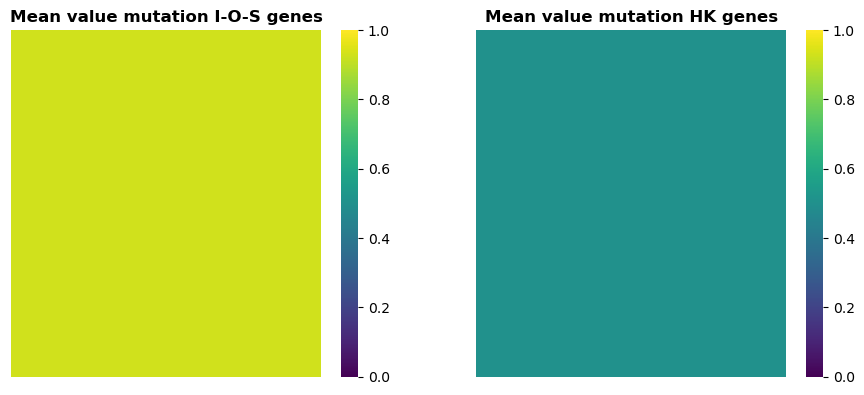

In [79]:
plt.subplots(1,2,figsize=(11,4.5))
plt.subplot(1,2,1)
sns.heatmap(IOS_genes,cmap="viridis", vmin=0, vmax=1)
plt.xticks([])
plt.yticks([])
plt.title("Mean value mutation I-O-S genes", fontweight="bold")
plt.subplot(1,2,2)
sns.heatmap(HK_genes,cmap="viridis", vmin=0, vmax=1)
plt.xticks([])
plt.yticks([])
plt.title("Mean value mutation HK genes", fontweight="bold")
plt.savefig("images/genes_"+gifname[:-4]+".png")